# Task 2 V2 — Machine Learning & NLP Analysis

**Dataset:** `data/fake_news_orig.csv` — misinformation / fake-news article dataset.

| Sub-task | Technique |
|----------|----------|
| 2.1 Correlation | Spearman correlation · interactive Plotly heatmap |
| 2.2 Regression | Polynomial regression (degree=2) via sklearn Pipeline |
| 2.3 Classification | Random Forest · CountVectorizer · top-20 word importances |
| 2.4 Network Graph | pyvis interactive HTML graph |
| 2.5 Word Clouds | Bigram-only word clouds with circular mask |

In [1]:
# Install required libraries
!pip install plotly scikit-learn pandas numpy wordcloud pyvis Pillow --quiet


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os
import warnings
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from wordcloud import WordCloud, STOPWORDS
from IPython.display import display, IFrame, HTML
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# ── Path resolution ───────────────────────────────────────────────────────────
# __vsc_ipynb_file__ is set by the VS Code kernel to the notebook's absolute path.
# This ensures V2/data/ is found regardless of what the kernel's CWD is.
try:
    _NB_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    _NB_DIR = os.getcwd()

def find_data_dir():
    '''Locate V2/data/ using the notebook file location, with CWD fallbacks.'''
    candidates = [
        os.path.join(_NB_DIR, '..', 'data'),   # V2/data  (preferred — self-contained)
        os.path.join(_NB_DIR, 'data'),          # notebook-local data/
        'data', '../data', '../../data',        # CWD-relative fallbacks
    ]
    for path in candidates:
        full = os.path.normpath(os.path.abspath(path))
        if os.path.isfile(os.path.join(full, 'fake_news_orig.csv')):
            return full
    raise FileNotFoundError('Cannot locate data/ directory containing fake_news_orig.csv')

DATA_DIR = find_data_dir()
print(f'Data directory: {DATA_DIR}')

# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv(os.path.join(DATA_DIR, 'fake_news_orig.csv'), low_memory=False)
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
display(df.head(3))

Data directory: /workspaces/2026-4-6-Data-Science-for-Cyber-Security/data
Shape: (12999, 20)
Columns: ['uuid', 'ord_in_thread', 'author', 'published', 'title', 'text', 'language', 'crawled', 'site_url', 'country', 'domain_rank', 'thread_title', 'spam_score', 'main_img_url', 'replies_count', 'participants_count', 'likes', 'comments', 'shares', 'type']


,uuid,ord_in_thread,author,published,title,text,language,crawled,site_url,country,domain_rank,thread_title,spam_score,main_img_url,replies_count,participants_count,likes,comments,shares,type
0,6a175f46bcd24d39b3e962ad0f29936721db70db,0,Barracuda Brigade,2016-10-26T21:41:00.000+03:00,Muslims BUSTED: They Stole Millions In Gov’t B...,Print They should pay all the back all the mon...,english,2016-10-27T01:49:27.168+03:00,100percentfedup.com,US,25689.0,Muslims BUSTED: They Stole Millions In Gov’t B...,0.0,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,0,1,0,0,0,bias
1,2bdc29d12605ef9cf3f09f9875040a7113be5d5b,0,reasoning with facts,2016-10-29T08:47:11.259+03:00,Re: Why Did Attorney General Loretta Lynch Ple...,Why Did Attorney General Loretta Lynch Plead T...,english,2016-10-29T08:47:11.259+03:00,100percentfedup.com,US,25689.0,Re: Why Did Attorney General Loretta Lynch Ple...,0.0,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,0,1,0,0,0,bias
2,c70e149fdd53de5e61c29281100b9de0ed268bc3,0,Barracuda Brigade,2016-10-31T01:41:49.479+02:00,BREAKING: Weiner Cooperating With FBI On Hilla...,Red State : \nFox News Sunday reported this mo...,english,2016-10-31T01:41:49.479+02:00,100percentfedup.com,US,25689.0,BREAKING: Weiner Cooperating With FBI On Hilla...,0.0,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,0,1,0,0,0,bias


## Task 2.1 — Spearman Correlation Heatmap
Spearman rank correlation is used instead of Pearson because it is
robust to non-normal distributions and monotonic (non-linear) relationships.

In [3]:
# ── Task 2.1: Spearman Correlation ───────────────────────────────────────────
numeric_cols = [
    'ord_in_thread', 'domain_rank', 'spam_score',
    'replies_count', 'participants_count', 'likes', 'comments', 'shares'
]
# Keep only columns that actually exist in the dataset
numeric_cols = [c for c in numeric_cols if c in df.columns]

# Replace empty strings with NaN, coerce to numeric, drop missing
num_df = df[numeric_cols].apply(pd.to_numeric, errors='coerce').dropna()

# Compute Spearman correlation matrix
spearman_corr, _ = stats.spearmanr(num_df)
corr_matrix = pd.DataFrame(spearman_corr, index=num_df.columns, columns=num_df.columns)

# Interactive Plotly heatmap
fig = go.Figure(
    go.Heatmap(
        z=corr_matrix.values,
        x=corr_matrix.columns.tolist(),
        y=corr_matrix.index.tolist(),
        colorscale='RdBu',
        zmin=-1, zmax=1,
        text=corr_matrix.round(2).values,
        texttemplate='%{text}',
        hovertemplate='%{y} vs %{x}: %{z:.3f}<extra></extra>',
        colorbar=dict(title='Spearman r')
    )
)
fig.update_layout(
    title='Task 2.1 — Spearman Correlation Matrix (Fake News Dataset)',
    template='plotly_dark',
    xaxis_tickangle=-45,
    height=550
)
fig.show()

# Identify top 3 correlated pairs (exclude self-correlations)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
top_pairs = (
    upper.stack()
    .abs()
    .sort_values(ascending=False)
    .head(3)
)
print('Top 3 Spearman-correlated pairs:')
print(top_pairs)

Top 3 Spearman-correlated pairs:
likes          shares                1.000000
ord_in_thread  replies_count         0.984410
replies_count  participants_count    0.534235
dtype: float64


## Task 2.2 — Polynomial Regression (degree=2)
A sklearn `Pipeline` combining `PolynomialFeatures` and `LinearRegression`
models non-linear relationships between the top correlated numerical pairs.

In [4]:
# ── Task 2.2: Polynomial Regression ─────────────────────────────────────────
poly_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('linreg', LinearRegression())
])

# Use the top 3 pairs from Task 2.1
top_pair_list = list(top_pairs.index)[:3]

fig = make_subplots(
    rows=1, cols=len(top_pair_list),
    subplot_titles=[
        f'Pair {i+1}: {p[0]} vs {p[1]}' for i, p in enumerate(top_pair_list)
    ]
)

for idx, (col_x, col_y) in enumerate(top_pair_list):
    pair_df = num_df[[col_x, col_y]].dropna()
    X = pair_df[[col_x]].values
    y = pair_df[col_y].values

    poly_pipe.fit(X, y)
    x_range = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
    y_pred = poly_pipe.predict(x_range)
    r2 = poly_pipe.score(X, y)

    col_pos = idx + 1
    # Scatter: observations
    fig.add_trace(
        go.Scatter(
            x=pair_df[col_x], y=pair_df[col_y],
            mode='markers',
            marker=dict(size=4, color='#3498db', opacity=0.5),
            name='Observations',
            showlegend=(idx == 0)
        ),
        row=1, col=col_pos
    )
    # Line: polynomial regression curve
    fig.add_trace(
        go.Scatter(
            x=x_range.flatten(), y=y_pred,
            mode='lines',
            line=dict(color='#e74c3c', width=2),
            name=f'Poly Fit (R²={r2:.3f})',
            showlegend=(idx == 0)
        ),
        row=1, col=col_pos
    )
    fig.update_xaxes(title_text=col_x, row=1, col=col_pos)
    fig.update_yaxes(title_text=col_y, row=1, col=col_pos)

fig.update_layout(
    title='Task 2.2 — Polynomial Regression (degree=2) on Top Correlated Pairs',
    template='plotly_dark',
    height=450
)
fig.show()

## Task 2.3 — Random Forest Text Classification
`CountVectorizer` (bag-of-words) converts article text to feature vectors.
A Random Forest classifier is trained to predict article `type`.
Feature importances are visualised as a bar chart of the top 20 most
predictive words.

In [5]:
# ── Task 2.3: Random Forest Text Classification ──────────────────────────────

# Prepare data: drop rows without text or type
clf_df = df[['text', 'type']].dropna(subset=['text', 'type'])
clf_df = clf_df[clf_df['text'].str.strip() != '']

# Keep only types with enough samples
type_counts = clf_df['type'].value_counts()
valid_types = type_counts[type_counts >= 30].index.tolist()
clf_df = clf_df[clf_df['type'].isin(valid_types)]
print(f'Classes used: {valid_types}')
print(f'Samples per class:\n{clf_df["type"].value_counts()}')

# Vectorise text with CountVectorizer
vectorizer = CountVectorizer(
    max_features=5000,
    stop_words='english',
    min_df=2
)
X = vectorizer.fit_transform(clf_df['text']).toarray()
y = clf_df['type'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print('\nClassification Report:')
print(classification_report(y_test, y_pred))

# Confusion matrix (Plotly)
cm = confusion_matrix(y_test, y_pred, labels=rf.classes_)
fig_cm = go.Figure(
    go.Heatmap(
        z=cm,
        x=list(rf.classes_),
        y=list(rf.classes_),
        colorscale='Blues',
        text=cm,
        texttemplate='%{text}',
        hovertemplate='True: %{y}<br>Pred: %{x}<br>Count: %{z}<extra></extra>'
    )
)
fig_cm.update_layout(
    title='Task 2.3 — Confusion Matrix: Random Forest Classifier',
    xaxis_title='Predicted Label',
    yaxis_title='True Label',
    template='plotly_dark',
    height=450
)
fig_cm.show()

# Top 20 most important words by Gini importance
feature_names = np.array(vectorizer.get_feature_names_out())
importances = rf.feature_importances_
top20_idx = np.argsort(importances)[-20:][::-1]
top20_df = pd.DataFrame({
    'Word': feature_names[top20_idx],
    'Importance': importances[top20_idx]
})

fig_imp = px.bar(
    top20_df, x='Importance', y='Word',
    orientation='h',
    title='Task 2.3 — Top 20 Most Predictive Words (Random Forest Gini Importance)',
    labels={'Importance': 'Feature Importance (Gini)', 'Word': 'Word'},
    color='Importance',
    color_continuous_scale='Blues',
    template='plotly_dark'
)
fig_imp.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    height=550
)
fig_imp.show()

Classes used: ['bs', 'bias', 'conspiracy', 'hate', 'state', 'junksci', 'satire']
Samples per class:
type
bs            11386
bias            441
conspiracy      430
hate            246
state           121
junksci         102
satire          100
Name: count, dtype: int64

Classification Report:
              precision    recall  f1-score   support

        bias       0.90      0.22      0.35        88
          bs       0.91      1.00      0.95      2278
  conspiracy       0.85      0.26      0.39        86
        hate       1.00      0.12      0.22        49
     junksci       0.00      0.00      0.00        21
      satire       1.00      0.15      0.26        20
       state       1.00      0.71      0.83        24

    accuracy                           0.91      2566
   macro avg       0.81      0.35      0.43      2566
weighted avg       0.90      0.91      0.88      2566



## Task 2.4 — Interactive Network Graph (pyvis)
An author-to-article network is built with `pyvis`. The resulting
interactive HTML graph is saved to `network_v2.html` and displayed inline.

In [6]:
# ── Task 2.4: pyvis Interactive Network Graph ────────────────────────────────
try:
    from pyvis.network import Network

    # Sample a manageable subset: top authors by article count
    net_df = df[['author', 'title', 'type', 'shares']].dropna(subset=['author', 'title'])
    net_df['shares'] = pd.to_numeric(net_df['shares'], errors='coerce').fillna(0)

    # Keep top 8 authors
    top_authors = net_df['author'].value_counts().head(8).index.tolist()
    net_sample = net_df[net_df['author'].isin(top_authors)].head(60)

    # Colour map for article types
    type_colours = {
        'bias': '#3498db', 'conspiracy': '#e74c3c',
        'satire': '#2ecc71', 'junksci': '#f39c12',
        'hate': '#9b59b6', 'fake': '#e67e22'
    }

    net = Network(
        height='620px', width='100%',
        bgcolor='#1a1a2e', font_color='white'
    )
    net.barnes_hut(gravity=-8000, central_gravity=0.3)

    # Add author nodes (gold stars)
    for author in net_sample['author'].unique():
        short_auth = str(author)[:25]
        net.add_node(
            short_auth, label=short_auth,
            color='#f1c40f', size=25, shape='star',
            title=f'Author: {author}'
        )

    # Add article nodes and edges
    for _, row in net_sample.iterrows():
        auth = str(row['author'])[:25]
        title_short = str(row['title'])[:40]
        art_type = str(row.get('type', 'unknown')).lower()
        colour = type_colours.get(art_type, '#95a5a6')
        if title_short not in net.node_ids:
            net.add_node(
                title_short, label=title_short,
                color=colour, size=10, shape='dot',
                title=f'Type: {art_type} | Shares: {int(row["shares"])}'
            )
        net.add_edge(auth, title_short, color='#7f8c8d', width=1)

    output_html = 'network_v2.html'
    net.save_graph(output_html)
    print(f'Network graph saved: {output_html}')

    display(IFrame(src=output_html, width='100%', height=650))

except ImportError:
    print('pyvis not available. Install with: pip install pyvis')
except Exception as exc:
    print(f'Network graph skipped: {exc}')

Network graph saved: network_v2.html


## Task 2.5 — Bigram Word Clouds with Circular Mask
Both word clouds use **bigrams only** (2-word phrases) extracted with
`CountVectorizer(ngram_range=(2,2))`. A circular NumPy mask is applied
to constrain the cloud to a circle shape.

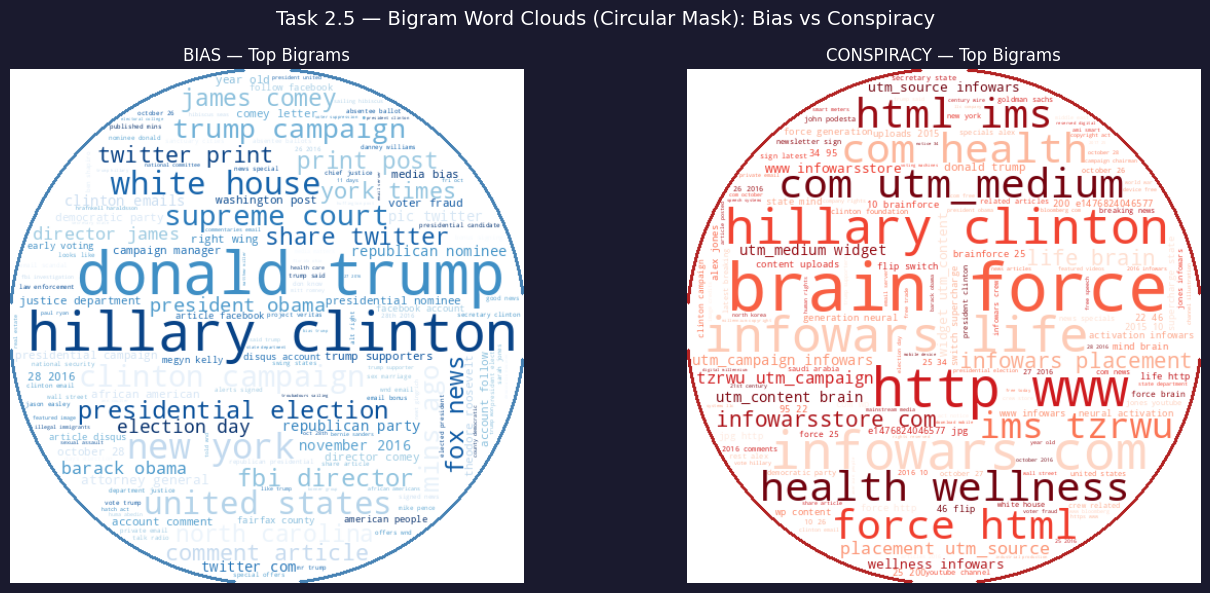

Word clouds saved: bigram_wordclouds_v2.png


In [7]:
# ── Task 2.5: Bigram Word Clouds with Circular Mask ──────────────────────────

def get_bigram_freqs(texts, max_features=200):
    '''
    Extract bigram (2-word) frequencies from a list of texts.

    Parameters:
        texts (list): List of text strings.
        max_features (int): Maximum number of bigrams to extract.

    Returns:
        dict: {bigram: frequency} mapping.
    '''
    cv = CountVectorizer(
        ngram_range=(2, 2),
        stop_words='english',
        max_features=max_features
    )
    cv.fit(texts)
    matrix = cv.transform(texts).toarray()
    totals = matrix.sum(axis=0)
    return dict(zip(cv.get_feature_names_out(), totals))

def make_circle_mask(size=400):
    '''Create a boolean circle mask array of given size.'''
    cx, cy, r = size // 2, size // 2, size // 2
    x, y = np.ogrid[:size, :size]
    outside = (x - cx)**2 + (y - cy)**2 > r**2
    mask = np.full((size, size), 255, dtype=np.uint8)
    mask[outside] = 0          # 0 = excluded region
    # WordCloud uses 255 = background, 0 = fill area
    return np.where(outside, 255, 0).astype(np.uint8)

# Select BIAS and CONSPIRACY articles
bias_texts = df[df['type'].str.lower() == 'bias']['text'].dropna().tolist()
conspiracy_texts = df[df['type'].str.lower() == 'conspiracy']['text'].dropna().tolist()

if len(bias_texts) < 5 or len(conspiracy_texts) < 5:
    print('Not enough samples for word cloud; trying all types split 50/50...')
    half = len(df) // 2
    bias_texts = df['text'].dropna().iloc[:half].tolist()
    conspiracy_texts = df['text'].dropna().iloc[half:].tolist()

circle_mask = make_circle_mask(500)

bias_freqs = get_bigram_freqs(bias_texts)
conspiracy_freqs = get_bigram_freqs(conspiracy_texts)

wc_bias = WordCloud(
    mask=circle_mask,
    background_color='white',
    colormap='Blues',
    contour_color='steelblue',
    contour_width=2,
    max_words=150,
    width=500, height=500
).generate_from_frequencies(bias_freqs)

wc_conspiracy = WordCloud(
    mask=circle_mask,
    background_color='white',
    colormap='Reds',
    contour_color='firebrick',
    contour_width=2,
    max_words=150,
    width=500, height=500
).generate_from_frequencies(conspiracy_freqs)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='#1a1a2e')
fig.suptitle(
    'Task 2.5 — Bigram Word Clouds (Circular Mask): Bias vs Conspiracy',
    fontsize=14, color='white'
)

axes[0].imshow(wc_bias, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('BIAS — Top Bigrams', color='white', fontsize=12)
axes[0].set_facecolor('#1a1a2e')

axes[1].imshow(wc_conspiracy, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('CONSPIRACY — Top Bigrams', color='white', fontsize=12)
axes[1].set_facecolor('#1a1a2e')

plt.tight_layout()
plt.savefig('bigram_wordclouds_v2.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()
print('Word clouds saved: bigram_wordclouds_v2.png')

## Summary

| Sub-task | Technique | Key Output |
|----------|-----------|------------|
| 2.1 | Spearman correlation | Interactive Plotly heatmap |
| 2.2 | Polynomial regression (degree=2) | sklearn Pipeline, R² per pair |
| 2.3 | Random Forest + CountVectorizer | Top-20 word importances bar chart |
| 2.4 | pyvis network graph | `network_v2.html` |
| 2.5 | Bigram word clouds + circle mask | `bigram_wordclouds_v2.png` |